In [1]:
import pandas as pd
import torch

In [2]:
df=pd.read_csv('../data/ticket_classification.csv')

In [3]:
import re
def clean_text_dl(text):
    if not isinstance(text, str):
        return ""

    # 1. Lowercase the text
    text = text.lower()

    # 2. Remove BOTH actual newlines and literal "\n" text strings
    text = text.replace("\n", " ").replace("\\n", " ").replace("\r", " ")

    # 3. Isolates punctuation marks with spaces
    text = re.sub(r"([.,!?():\"'])", r" \1 ", text)

    # 4. Remove extra spaces and squash down to a single clean space
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [4]:
subject=df.iloc[1]['subject']
subject

'Query About Smart Home System Integration Features'

In [5]:
body=df.iloc[1]['body']
body

'Dear Customer Support Team,\\n\\nI hope this message reaches you well. I am reaching out to request detailed information about the capabilities of your smart home integration products listed on your website. As a potential customer aiming to develop a seamlessly interconnected home environment, it is essential to understand how your products interact with various smart home platforms.\\n\\nCould you kindly provide detailed compatibility information with popular smart home ecosystems such as Amazon Alexa, Google Assistant, and Apple?'

In [6]:
queue=df.iloc[1]['queue']
queue

'Returns and Exchanges'

In [7]:
from transformers import DistilBertTokenizerFast
from transformers import DistilBertForSequenceClassification

tokenizer = DistilBertTokenizerFast.from_pretrained(
    "../models/queue_tokenizer"
)

model = DistilBertForSequenceClassification.from_pretrained(
    "../models/queue_model",
    output_attentions=True
)

model.eval()

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [8]:
text = clean_text_dl(subject +' '+ body)
text

'query about smart home system integration features dear customer support team , i hope this message reaches you well . i am reaching out to request detailed information about the capabilities of your smart home integration products listed on your website . as a potential customer aiming to develop a seamlessly interconnected home environment , it is essential to understand how your products interact with various smart home platforms . could you kindly provide detailed compatibility information with popular smart home ecosystems such as amazon alexa , google assistant , and apple ?'

In [9]:
inputs = tokenizer(
    text,
    return_tensors="pt",
    truncation=True,
    max_length=128
)

In [10]:
with torch.no_grad():
    outputs = model(**inputs)

    logits = outputs.logits

    probs = torch.softmax(logits, dim=1)

    pred_class = torch.argmax(probs, dim=1).item()

    confidence = probs[0][pred_class].item()

pred_class, confidence

(6, 0.8007493615150452)

In [11]:
import json

with open("../models/id2label.json") as f:
    id2label = json.load(f)

In [12]:
queue_name = id2label[str(pred_class)]

print(queue_name)

Returns and Exchanges


In [13]:
inputs = tokenizer(
    text,
    return_tensors="pt",
    truncation=True,
    max_length=128
)

with torch.no_grad():

    outputs = model(
        **inputs,
        output_attentions=True
    )

In [14]:
print(len(outputs.attentions))

6


In [15]:
attentions = outputs.attentions

last_layer = attentions[-1]

In [16]:
print(last_layer.shape)

torch.Size([1, 12, 97, 97])


In [17]:
attention_scores = (
    last_layer[0]
    .mean(dim=0)
    .mean(dim=0)
)

In [18]:
tokens = tokenizer.convert_ids_to_tokens(
    inputs["input_ids"][0]
)

In [19]:
import pandas as pd

attention_df = pd.DataFrame({
    "token": tokens,
    "attention": attention_scores.cpu().numpy()
})

attention_df = attention_df.sort_values(
    "attention",
    ascending=False
)

attention_df.head(20)

,token,attention
42,.,0.099836
20,.,0.043692
92,",",0.034682
78,compatibility,0.030068
57,",",0.028921
96,[SEP],0.027957
45,potential,0.027204
37,products,0.020429
64,your,0.019978
65,products,0.019224


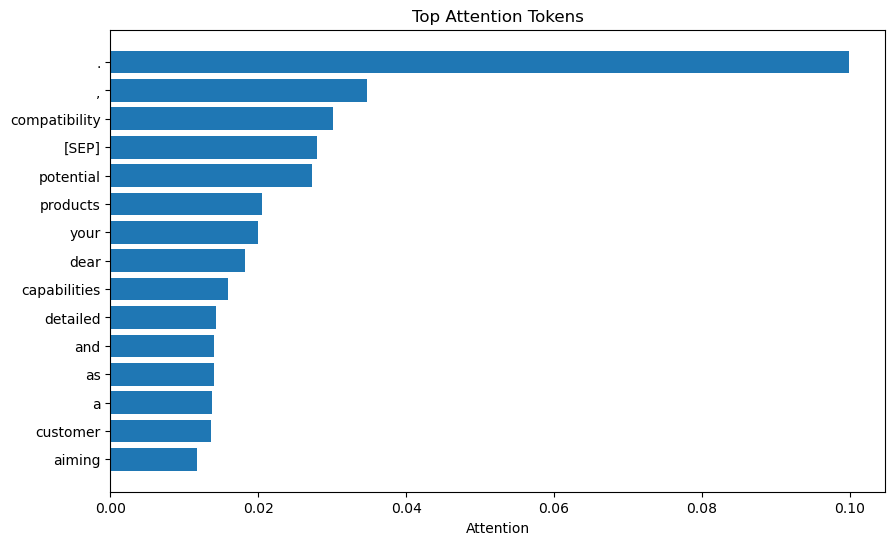

In [20]:
import matplotlib.pyplot as plt

top_tokens = attention_df.head(20)

plt.figure(figsize=(10,6))

plt.barh(
    top_tokens["token"],
    top_tokens["attention"]
)

plt.gca().invert_yaxis()

plt.title(
    "Top Attention Tokens"
)

plt.xlabel("Attention")

plt.show()

In [21]:
attention_map = pd.DataFrame({
    "token": tokens,
    "attention": attention_scores.cpu().numpy()
})

attention_map = attention_map.sort_values(
    "attention",
    ascending=False
)

print(
    attention_map.head(20)
)

            token  attention
42              .   0.099836
20              .   0.043692
92              ,   0.034682
78  compatibility   0.030068
57              ,   0.028921
96          [SEP]   0.027957
45      potential   0.027204
37       products   0.020429
64           your   0.019978
65       products   0.019224
8            dear   0.018193
31   capabilities   0.015956
33           your   0.014367
27       detailed   0.014286
72              .   0.014217
93            and   0.013975
43             as   0.013966
44              a   0.013754
46       customer   0.013654
47         aiming   0.011770


In [24]:
attention_df = attention_df[
    ~attention_df["token"].isin(
        ["[CLS]", "[SEP]", "[PAD]",',','.']
    )
]

attention_df = attention_df[
    ~attention_df["token"].str.startswith("##")
]

attention_df.head(15)

,token,attention
78,compatibility,0.030068
45,potential,0.027204
37,products,0.020429
64,your,0.019978
65,products,0.019224
8,dear,0.018193
31,capabilities,0.015956
33,your,0.014367
27,detailed,0.014286
93,and,0.013975


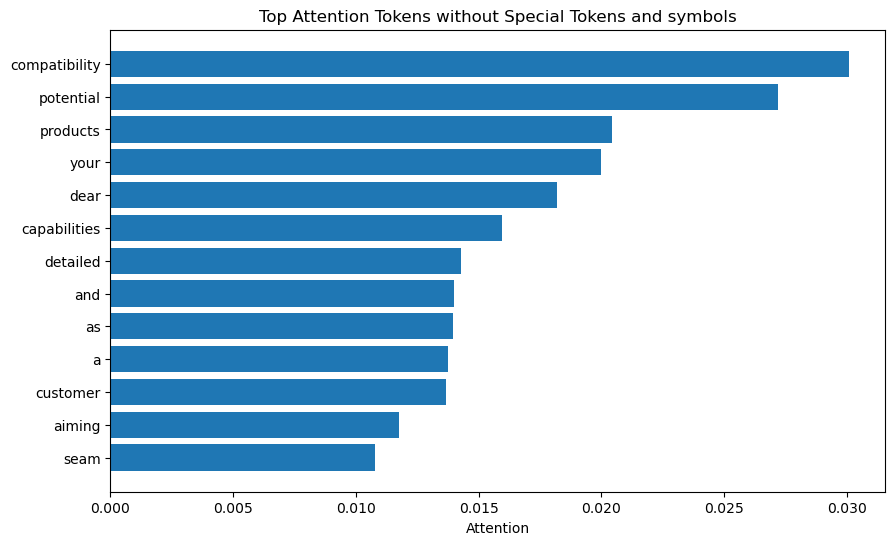

In [26]:
attention_df=attention_df.head(15)
plt.figure(figsize=(10,6))

plt.barh(
    attention_df["token"],
    attention_df["attention"]
)

plt.gca().invert_yaxis()

plt.title(
    "Top Attention Tokens without Special Tokens and symbols"
)

plt.xlabel("Attention")

plt.show()